In [8]:

import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import os
import logging
import warnings
from transformers import AutoModelForCausalLM
from scipy.linalg import hadamard # Hadamard 행렬 생성을 위해 추가
import constriction

plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['figure.titlesize'] = 20

# ==========================================
# 1. 초기 설정 (Imports & Setup)
# ==========================================
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'qtip'))
if project_root not in sys.path:
    sys.path.append(project_root)

# qtip 라이브러리가 없다면 에러가 날 수 있으므로 주의 (사용자 환경 전제)
try:
    from lib.codebook.bitshift import bitshift_codebook
    from lib.codebook.bitshift_exp import bitshift_codebook as bitshift_codebook_exp
except ImportError:
    print("Warning: 'qtip' library not found. Ensure project_root is correct.")

import torch._dynamo
import scipy.stats

# 에러 및 경고 억제
torch._dynamo.config.suppress_errors = True
torch._dynamo.reset()
logging.getLogger('torch._dynamo').setLevel(logging.ERROR) 
logging.getLogger('torch._inductor').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 시드 고정
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda:7'
N_SAMPLES = 1024 * 256
# N_SAMPLES = 1024 * 1024 * 16

# ==========================================
# 2. Model Weights 로딩
# ==========================================
print("Loading Model Weights...")

def get_named_linears(module):
    return {name: m for name, m in module.named_modules() if isinstance(m, nn.Linear)}

def get_blocks(model):
    if model.__class__.__name__ in ("LlamaForCausalLM", "Qwen2ForCausalLM"):
        layers = model.model.layers
    else:
        raise NotImplementedError(type(model))
    return layers

model_list = ['meta-llama/Meta-Llama-3-8B']
weight_norm = None

try:
    for model_name in model_list:
        model_name_safe = model_name.replace('/', '--')
        model_path = f"../Wparam_dataset/hf_model/{model_name_safe}"
        
        if not os.path.exists(model_path):
            print(f"Warning: Model path {model_path} not found. Skipping Weight experiment.")
            continue

        print(f'Loading from: {model_path}')
        model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True)
        layers = get_blocks(model)
        
        weight = []
        for i in tqdm(range(len(layers)), desc="Extracting Weights"):
            named_linears = get_named_linears(layers[i])
            for n, m in named_linears.items():
                W = m.weight.data.detach().view(-1)
                weight.append(W)
        
        weight = torch.cat(weight, dim=0)
        
        mean = weight.mean()
        std = weight.std()
        weight_norm = (weight - mean) / std
        
        print(f"Weights Loaded: Mean={mean.item():.4f}, Std={std.item():.4f}")
        print(f"Normalized: Mean={weight_norm.mean().item():.4f}, Std={weight_norm.std().item():.4f}")
        
        del model
        torch.cuda.empty_cache()
        break 

except Exception as e:
    print(f"Error loading weights: {e}")
    weight_norm = None

def apply_rht(data, block_size=256):
    """
    Randomized Hadamard Transform 적용
    1. 데이터를 (N, BlockSize)로 Reshape
    2. Random Sign Flipping (Bernoulli 0.5)
    3. Walsh-Hadamard Transform 적용
    """
    n = len(data)
    # 패딩 (BlockSize 배수가 아닐 경우)
    pad = (block_size - (n % block_size)) % block_size
    if pad > 0:
        data = torch.cat([data, torch.zeros(pad, device=data.device, dtype=data.dtype)])
    
    data_2d = data.view(-1, block_size).to(device)
    
    signs = torch.randint(0, 2, data_2d.shape, device=device).to(dtype=data.dtype) * 2 - 1
    data_signed = data_2d * signs
    
    H_np = hadamard(block_size)
    H = torch.from_numpy(H_np).to(device).type_as(data_signed)
    scale = 1.0 / np.sqrt(block_size)
    data_transformed = torch.matmul(data_signed, H) * scale
    
    return data_transformed.view(-1)[:n].cpu()

def calc_entropy(labels, verbose = False):
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    if verbose:
        print(probs.shape)
    return -np.sum(probs * np.log2(probs + 1e-10))

def uniform_quantization(x, step_size):
    if step_size < 1e-6: return x 
    return np.round(x / step_size) * step_size

from sklearn.cluster import MiniBatchKMeans

import scipy.stats
from scipy.cluster.vq import vq

def run_vq_entropy_experiment_gaussian(data_tensor, dim=2, target_bit=2):
    n = len(data_tensor)
    n_vec = (n // dim) * dim
    data_np = data_tensor[:n_vec].view(-1, dim).detach().cpu().numpy()
    k_bits = target_bit * dim
    if k_bits > 16:
        print(f"Warning: Codebook size 2^{k_bits} is too large. Caps at 2^16.")
        k_bits = 16
    
    n_clusters = int(2 ** k_bits)
    
    if n_clusters > len(data_np):
        n_clusters = len(data_np)

    centroids = np.random.normal(loc=0.0, scale=1.0, size=(n_clusters, dim))
    data_mean = np.mean(data_np)
    data_std = np.std(data_np)
    centroids = centroids * data_std + data_mean

    labels, _ = vq(data_np, centroids)
    
    recon_data = centroids[labels]
    
    mse = np.mean((data_np - recon_data) ** 2)
    
    _, counts = np.unique(labels, return_counts=True)
    entropy_per_vector = scipy.stats.entropy(counts, base=2)
    actual_bpp = entropy_per_vector / dim
    
    return actual_bpp, mse

from sklearn.cluster import MiniBatchKMeans

def run_gaussian_vq_only(data_tensor, dim=2, target_bit=2):
    """
    Entropy 계산 없이, Gaussian Codebook을 이용한 VQ 수행 후 
    MSE와 재구성된 데이터(Reconstructed Data)를 반환합니다.
    """
    n = len(data_tensor)
    n_vec = (n // dim) * dim
    data_np = data_tensor[:n_vec].view(-1, dim).detach().cpu().numpy()
    
    k_bits = target_bit * dim
    
    if k_bits > 16:
        k_bits = 16
    
    n_clusters = int(2 ** k_bits)
    if n_clusters > len(data_np):
        n_clusters = len(data_np)
        
    # centroids = np.random.normal(loc=0.0, scale=1.0, size=(n_clusters, dim))
    # data_mean = np.mean(data_np)
    # data_std = np.std(data_np)
    # centroids = centroids * data_std + data_mean
    # labels, _ = vq(data_np, centroids)
    
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters, 
        batch_size=1024,
        n_init=3,
        max_iter=50, # 학습 반복
        random_state=42
    )
    kmeans.fit(data_np)
    centroids = kmeans.cluster_centers_
    labels = kmeans.predict(data_np)
    
    recon_data = centroids[labels]
    mse = np.mean((data_np - recon_data) ** 2)
    
    return mse

def run_actual_rans(data_np, step_size):
    """
    실제 rANS 인코더를 사용하여 압축 비트레이트를 측정합니다.
    """
    q_indices = np.round(data_np / step_size).astype(np.int32)
    
    # 2. 심볼 오프셋 조정 (constriction은 0부터 시작하는 양의 정수 필요)
    min_val = q_indices.min()
    symbols = q_indices - min_val # 0, 1, 2, ... 로 변환
    symbols = symbols.astype(np.int32) # constriction은 int32 요구
    
    # 3. 확률 모델 생성 (Frequency Table)
    # 실제 압축에선 이 'probs' 정보도 헤더에 저장해야 하지만, 
    # 여기선 Raw Data Stream의 압축 효율만 비교합니다.
    unique, counts = np.unique(symbols, return_counts=True)
    
    # 빈 심볼도 포함하여 확률 테이블 생성 (max_val 까지)
    max_sym = symbols.max()
    freqs = np.zeros(max_sym + 1, dtype=np.float64)
    freqs[unique] = counts
    
    probs = freqs / freqs.sum()
    
    model = constriction.stream.model.Categorical(probs)
    
    coder = constriction.stream.stack.AnsCoder()
    # 인코더에 데이터 주입 (Stack 방식이라 reverse로 넣는 것이 일반적이나, 순서는 bpp에 영향 없음)
    coder.encode_reverse(symbols, model)
    compressed_data = coder.get_compressed() 
    total_bits = len(compressed_data) * 32 
    
    actual_bpp = total_bits / len(data_np)
    
    return actual_bpp

def run_qtip_experiment(data_tensor, decode_mode, K=2, V=2, L=16, tlut_bits=None, init_dist = 'gaussian'):
    if tlut_bits is None:
        tlut_bits = max(9, 2*K + 1)
        
    cb = bitshift_codebook_exp(
        L=L, K=K, V=V, 
        tlut_bits=tlut_bits, 
        decode_mode=decode_mode,
        init_dist = init_dist
    ).to(device)
    
    # 입력 처리: (Batch, BlockSize=256)
    # 데이터가 256의 배수가 아니면 잘릴 수 있으니 패딩 처리 또는 resize 필요
    # 여기서는 간단히 view가 가능한 크기로 가정
    current_len = data_tensor.shape[0]
    trim_len = (current_len // 256) * 256
    data_in = data_tensor[:trim_len].view(-1, 256).to(device)
    
    with torch.no_grad():
        q_out = cb.quantize(data_in)
        recon = q_out[0]
        mse = torch.mean((data_in - recon) ** 2).item()
    
    del cb
    
    return mse

def get_shannon_limit(data_np, R, source_name):
    """
    Shannon Lower Bound (SLB) 계산
    RHT가 적용된 소스는 'Gaussian'으로 간주하여 SLB 계산 (가우시안화 효과 반영)
    """
    sigma_sq = np.var(data_np)
    
    if "Gaussian" in source_name:
        return sigma_sq * (2 ** (-2 * R))
        
    elif "Laplace" in source_name and "RHT" not in source_name:
        # 순수 Laplace
        return (np.e / np.pi) * sigma_sq * (2 ** (-2 * R))
        
    else:
        # 일반 Model Weights 또는 RHT가 적용되지 않은 기타 분포
        # 데이터가 너무 많으면 샘플링
        sample_for_ent = data_np if len(data_np) < 20000 else np.random.choice(data_np, 20000)
        h_X = scipy.stats.differential_entropy(sample_for_ent, method='vasicek')
        coeff = (1.0 / (2 * np.pi * np.e)) * np.exp(2 * h_X)
        return coeff * (2 ** (-2 * R))

# ==========================================
# 4. Data Generators
# ==========================================
def get_gaussian_data():
    return torch.randn(N_SAMPLES)

def get_laplace_data():
    m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0 / np.sqrt(2)]))
    return m.sample((N_SAMPLES,)).squeeze()

def get_weight_data():
    if weight_norm is None:
        raise ValueError("Weights not loaded properly.")
    # 전체 웨이트에서 랜덤 샘플링 (블록 처리를 위해 256 배수 유지)
    indices = torch.randint(0, len(weight_norm), (N_SAMPLES,))
    return weight_norm[indices]


# 실험 리스트 정의
experiments = [
    ("Gaussian", get_gaussian_data),
    ("Laplace", get_laplace_data),
]

experiments.append(("Laplace + RHT", get_laplace_data))

if weight_norm is not None:
    experiments.append(("Model Weights", get_weight_data))
    experiments.append(("Model Weights + RHT", get_weight_data))

Loading Model Weights...
Loading from: ../Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B


Extracting Weights: 100%|██████████| 32/32 [00:00<00:00, 67.38it/s]


Weights Loaded: Mean=-0.0000, Std=0.0125
Normalized: Mean=-0.0000, Std=1.0000


In [9]:
import numpy as np
from numpy.random import random
from math import log
import copy


def dist(a, b):
    diff = a - b
    return np.sqrt((diff * diff).sum())


def init(data, k):
    """kmeans++ initialization."""
    centroid = [data[int(len(data) * random())]]

    # Cache dist table to prevent duplicate computations
    cache = [-1.0] * len(data)
    recent_centroid = centroid[0]

    while len(centroid) < k:
        dist_list = []
        for i in range(len(data)):
            candidate = dist(data[i], recent_centroid)
            d = candidate if cache[i] < 0 else min(candidate, cache[i])
            cache[i] = d
            dist_list.append(d)
        arrow = sum(dist_list) * random()
        for i in range(len(dist_list)):
            arrow -= dist_list[i]
            if arrow <= 0:
                centroid.append(data[i])
                recent_centroid = data[i]
                break
    return centroid


def ECVQ(data, k, l, max_iters=300, verbose=False):
    """k is the maximum number of clusters, l is the lagrange limitation."""

    # Initial variables
    total = len(data)
    alpha = 1e-12
    matrix = np.zeros(k)
    cache = np.zeros((total, k))
    mapping = np.zeros(total, dtype=int)
    update_list = np.ones(k, dtype=int)

    # Force lookup table enumerate all possible lambda force
    force = [l * log((float(i) / total) + alpha) for i in range(total)]

    # Initial the centroid with kmeans++
    centroid = init(data, k)

    for iters in range(max_iters):
        diff = 0.0

        # Assign each data point to its cluster
        centroid_member = [[] for _ in centroid]
        next_update = np.zeros_like(update_list, dtype=int)

        for i in range(total):
            for j in range(k):
                if update_list[j]:
                    matrix[j] = dist(data[i], centroid[j]) - force[len(centroid_member[j])]
                    cache[i][j] = matrix[j]
                else:
                    matrix[j] = cache[i][j]

            classes = matrix.argmin()
            diff += matrix.min()

            t = mapping[i]
            if t != classes:
                next_update[t] = 1
                next_update[classes] = 1
            mapping[i] = classes
            centroid_member[classes].append(i)

        # Update centroids
        update_id = 0
        for c in centroid_member:
            if len(c) and next_update[update_id]:
                updated = np.zeros_like(data[0])
                for i in range(len(c)):
                    updated += data[c[i]]
                updated /= len(c)
                centroid[update_id] = copy.deepcopy(updated)
            update_id += 1
        update_list = copy.deepcopy(next_update)

        count = sum(1 for c in centroid_member if len(c) > 0)

        if verbose:
            print(iters, diff, count)

    return centroid, centroid_member, mapping


def _ensure_2d(data):
    data = np.asarray(data)
    if data.ndim == 1:
        return data.reshape(-1, 1)
    return data


def ecvq_rate_mse(data, k, l, max_iters=300, verbose=False):
    data = _ensure_2d(data)
    k = int(min(max(k, 2), len(data)))

    centroids, _, mapping = ECVQ(data, k, l, max_iters=max_iters, verbose=verbose)
    centroid_arr = np.stack(centroids, axis=0)
    recon = centroid_arr[mapping]
    mse = np.mean((data - recon) ** 2)
    rate = calc_entropy(mapping) / data.shape[1]
    return rate, mse, centroids, mapping


def search_lambda_for_rate(
    data,
    k,
    target_rate,
    l_min=1e-3,
    l_max=1e3,
    steps=12,
    max_iters=100,
    sample_size=50000,
):
    data = _ensure_2d(data)
    if sample_size and len(data) > sample_size:
        idx = np.random.choice(len(data), sample_size, replace=False)
        data = data[idx]

    k = int(min(max(k, 2), len(data)))

    low, high = l_min, l_max
    best_l = None
    best_rate = None
    best_mse = None
    best_err = float('inf')

    for _ in range(steps):
        mid = (low * high) ** 0.5
        rate, mse, _, _ = ecvq_rate_mse(data, k, mid, max_iters=max_iters, verbose=False)
        err = abs(rate - target_rate)
        if err < best_err:
            best_err = err
            best_l = mid
            best_rate = rate
            best_mse = mse

        if rate > target_rate:
            low = mid
        else:
            high = mid

    return best_l, best_rate, best_mse


In [ ]:
# ==========================================
# 5. Main Experiment Loop
# ==========================================
R_targets = range(2, 9)
# R_targets = [6]

Total_results = {}

for source_name, data_gen_func in experiments:
    print(f"\n{'='*40}")
    print(f"Running Experiment: {source_name}")
    print(f"{'='*40}")
    
    # 1. 데이터 생성
    data = data_gen_func()
    
    # 2. RHT 적용 여부 확인 및 변환
    is_rht = "RHT" in source_name
    if is_rht:
        print(f"Applying Randomized Hadamard Transform to {source_name}...")
        data = apply_rht(data, block_size=256)
    
    data_np = data.numpy()
    
    print(f"[{source_name}] Stats: Mean={data.mean():.4f}, Std={data.std():.4f}")
    
    results = {
        "R": [],       # 목표 Rate (Loop 기준)
        "Shannon": [],        # Shannon Limit
        "SQ_Fixed_MSE": [],   # SQ (Lloyd-Max) MSE
        "SQ_Ent_Theory_Rate": [], # 이론적 엔트로피 (X축)
        "SQ_Ent_MSE": [],         # SQ + Entropy MSE (Y축)
        "SQ_rANS_Rate": [],  
        
        "1D_TCQ_1MAD": [], 
        "1D_TCQ_3INST": [], 
        
        "2D_TCQ_HYB": [], 
        "2D_TCQ_HYB_laplace": [], 
        '1D_TCQ_HYB': [],
        
        "2D_TCQ_RPTC": [],
        "2D_TCQ_RPTC_laplace": [],
        '1D_TCQ_RPTC': [],
        
        '2D_TCQ_HYB*': [],
        '2D_TCQ_HYB*_laplace': [],
        '1D_TCQ_HYB*': [],
        
        '2D_TCQ_HYB_asym': [],
        '1D_TCQ_HYB_asym': [],
        '2D_TCQ_HYB_asym*': [],
        '1D_TCQ_HYB_asym*': [],
        
        'VQ_d2_Entropy_Rate': [],
        'VQ_d2_Entropy_MSE': [],
        'VQ_d4_Entropy_Rate': [],
        'VQ_d4_Entropy_MSE': [],
        
        'VQ_d4_MSE': [],
        'VQ_d2_MSE': [],
    }
    
    print("-" * 110)
    print(f"{'Rate':<5} | {'Shannon':<10} | {'SQ(Fix)':<10} | {'SQ(Ent)':<10} | {'1MAD':<10} | {'3INST':<10} | {'HYB':<10} | {'RPTC':<10}")
    print("-" * 110)

    for R_target in tqdm(R_targets, desc=f"Simulating ({source_name})"):
        results["R"].append(R_target)
        
        # Shannon Limit: RHT 적용 시 Gaussian 분포로 가정하여 비교
        slb_source_name = "Gaussian" if is_rht else source_name
        D_shannon = get_shannon_limit(data_np, R_target, slb_source_name)
        results["Shannon"].append(D_shannon)

        # # 2. SQ (Lloyd-Max)
        # n_clusters = 2 ** R_target
        # kmeans = KMeans(n_clusters=n_clusters, n_init=3, max_iter=50, random_state=42)
        # # 샘플이 너무 많으면 KMeans가 느리므로 10만개로 제한하여 학습
        # train_data = data_np if len(data_np) < 100000 else np.random.choice(data_np, 100000, replace=False)
        # kmeans.fit(train_data.reshape(-1, 1))
        
        # # 전체 데이터에 대한 예측
        # # 메모리 절약을 위해 배치 처리 혹은 전체 처리 (여기선 간단히 전체)
        # # 1D quantization mse ~ inertia / N
        # # 정확한 계산을 위해 predict 사용
        # q_indices = kmeans.predict(data_np.reshape(-1, 1))
        # centers = kmeans.cluster_centers_.flatten()
        # sq_recon = centers[q_indices]
        # sq_mse = np.mean((data_np - sq_recon)**2)
        # results["SQ_Fixed_MSE"].append(sq_mse)

        # 3. SQ + Entropy
        low, high = 0.001, 10.0
        best_step = 1.0
        # 이진 탐색으로 타겟 Rate(Entropy)에 맞는 step size 찾기
        sample_for_ent = data_np if len(data_np) < 50000 else data_np[:50000]
        
        for _ in range(15): 
            mid = (low + high) / 2
            q_vals = np.round(sample_for_ent / mid)
            h = calc_entropy(q_vals)
            if h > R_target: low = mid
            else: high = mid; best_step = mid
        
        ecsq_recon = uniform_quantization(data_np, best_step)
        ecsq_mse = np.mean((data_np - ecsq_recon)**2)
        
        q_vals_full = np.round(data_np / best_step)
        print(R_target)
        theory_rate = calc_entropy(q_vals_full, verbose= True)
        
        rans_rate = run_actual_rans(data_np, best_step)
        
        # results["SQ_Ent_Theory_Rate"].append(theory_rate) # X1
        # results["SQ_rANS_Rate"].append(rans_rate)         # X2 (New)
        # results["SQ_Ent_MSE"].append(ecsq_mse)            # Y (Common)
        
        # if R_target * 2 <= 14: # 코드북 크기 제한 (2^14 = 16384)
        #     # rate_d2, mse_d2 = run_vq_entropy_experiment_gaussian(data, dim=2, target_bit=R_target)
        #     # results["VQ_d2_Entropy_Rate"].append(rate_d2)
        #     # results["VQ_d2_Entropy_MSE"].append(mse_d2)
        #     results["VQ_d2_MSE"].append(run_gaussian_vq_only(data, dim=2, target_bit=R_target))
        # else:
        #     # results["VQ_d2_Entropy_Rate"].append(None)
        #     # results["VQ_d2_Entropy_MSE"].append(None)
        #     results["VQ_d2_MSE"].append(None)

        # if R_target * 4 < 16: 
        #     # rate_d4, mse_d4 = run_vq_entropy_experiment_gaussian(data, dim=4, target_bit=R_target)
        #     # results["VQ_d4_Entropy_Rate"].append(rate_d4)
        #     # results["VQ_d4_Entropy_MSE"].append(mse_d4)
        #     results["VQ_d4_MSE"].append(run_gaussian_vq_only(data, dim=4, target_bit=R_target))
        # else:
        #     # results["VQ_d4_Entropy_Rate"].append(None)
        #     # results["VQ_d4_Entropy_MSE"].append(None)                
        #     results["VQ_d4_MSE"].append(None)
        
        # tcq_1mad = run_qtip_experiment(data, decode_mode='1mad', K=R_target, V=1, tlut_bits=0)
        # results["1D_TCQ_1MAD"].append(tcq_1mad)
        
        # tcq_3inst = run_qtip_experiment(data, decode_mode='3inst', K=R_target, V=1, tlut_bits=0)
        # results["1D_TCQ_3INST"].append(tcq_3inst)

        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=9)
        # results["2D_TCQ_HYB"].append(tcq_hyb)
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=9, init_dist='laplace')
        # results["2D_TCQ_HYB_laplace"].append(tcq_hyb)
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=1, tlut_bits=9)
        # results["1D_TCQ_HYB"].append(tcq_hyb)
        
        # try:
        #     tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None)
        #     results["2D_TCQ_HYB*"].append(tcq_hyb)
        # except:
        #     results["2D_TCQ_HYB*"].append(None)
        # try:
        #     assert R_target <= 7
        #     tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None, init_dist='laplace')
        #     results["2D_TCQ_HYB*_laplace"].append(tcq_hyb)
        # except Exception as e:
        #     print(e)
        #     results["2D_TCQ_HYB*_laplace"].append(None)
            
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None, init_dist='laplace')
        # results["2D_TCQ_HYB*_laplace"].append(tcq_hyb)
            
        # try:
        #     tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=1, tlut_bits=None)
        #     results["1D_TCQ_HYB*"].append(tcq_hyb)
        # except:
        #     results["1D_TCQ_HYB*"].append(None)
            
        # try:
        #     tcq_rptc = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=2, tlut_bits=16)
        #     results["2D_TCQ_RPTC"].append(tcq_rptc)
        # except:
        #     results["2D_TCQ_RPTC"].append(None)
        # try:
        #     tcq_rptc = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=2, tlut_bits=16, init_dist='laplace')
        #     results["2D_TCQ_RPTC_laplace"].append(tcq_rptc)
        # except:
        #     results["2D_TCQ_RPTC_laplace"].append(None)
        # try:
        #     tcq_rptc_1d = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=1, tlut_bits=16)
        #     results["1D_TCQ_RPTC"].append(tcq_rptc_1d)
        # except:
        #     results["1D_TCQ_RPTC"].append(None)

        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=1, tlut_bits=None)
        # results["1D_TCQ_HYB_Q=2*K+1"].append(tcq_hyb)
        
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut', K=R_target, V=2, tlut_bits=9)
        # results["2D_TCQ_HYB_asym"].append(tcq_hyb)
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut', K=R_target, V=2, tlut_bits=None)
        # results["2D_TCQ_HYB_asym_Q=2*K+1"].append(tcq_hyb)
        
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut', K=R_target, V=1, tlut_bits=9)
        # results["1D_TCQ_HYB_asym"].append(tcq_hyb)
        # tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut', K=R_target, V=1, tlut_bits=None)
        # results["1D_TCQ_HYB_asym_Q=2*K+1"].append(tcq_hyb)        

        # print(f"{R_target:<5} | {D_shannon:<10.5f} | {sq_mse:<10.5f} | {ecsq_mse:<10.5f} | {tcq_1mad:<10.5f} | {tcq_3inst:<10.5f} | {tcq_hyb:<10.5f} | {tcq_rptc:<10.5f}")
        # print(f"{R_target:<5} | {D_shannon:<10.5f}")

    Total_results[source_name] = results    

# torch.save(Total_results, './toy_codec_comparision/6bit_tcq_init_laplace_1024_256.pkl')
# import json
# with open('./toy_codec_comparision/2-9bit_ecvq.json', 'w', encoding='utf-8') as file:
#     json.dump(Total_results, file, indent=4, ensure_ascii=False)  # Python 객체를 JSON 파일로 저장



Running Experiment: Gaussian
[Gaussian] Stats: Mean=-0.0002, Std=1.0022
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Gaussian):   0%|          | 0/7 [00:00<?, ?it/s]

Simulating (Gaussian):  57%|█████▋    | 4/7 [00:00<00:00, 33.58it/s]

2
(9,)
3
(19,)
4
(37,)
5
(70,)
6
(134,)
7
(256,)


Simulating (Gaussian): 100%|██████████| 7/7 [00:00<00:00, 29.26it/s]


...

2
(9,)
3


Simulating (Model Weights + RHT):  57%|█████▋    | 4/7 [00:00<00:00, 33.22it/s]

(18,)
4
(35,)
5
(67,)
6
(131,)
7
(255,)


Simulating (Model Weights + RHT): 100%|██████████| 7/7 [00:00<00:00, 28.92it/s]

8
(492,)


In [ ]:
R_targets = [2, 3, 4, 5, 6, 7, 8]

ECVQ_MAX_ITERS = 120
ECVQ_SEARCH_STEPS = 12
ECVQ_SEARCH_MAX_ITERS = 20
ECVQ_SAMPLE_SIZE = 1000
ECVQ_L_MIN = 1e-3
ECVQ_L_MAX = 1e3

Total_results = {}

for source_name, data_gen_func in experiments:
    print()
    print("=" * 40)
    print(f"Running Experiment: {source_name}")
    print("=" * 40)
    
    # 1. 데이터 생성
    data = data_gen_func()
    
    # 2. RHT 적용 여부 확인 및 변환
    is_rht = "RHT" in source_name
    if is_rht:
        print(f"Applying Randomized Hadamard Transform to {source_name}...")
        data = apply_rht(data, block_size=256)
    
    data_np = data.numpy()
    
    print(f"[{source_name}] Stats: Mean={data.mean():.4f}, Std={data.std():.4f}")
    
    results = {
        "R": [],       # 목표 Rate (Loop 기준)
        "ECSQ_Rate": [],
        "ECSQ_MSE": [],
        "ECSQ_lambda": [],
    }
    
    print("-" * 70)
    print(f"{'Target':<6} | {'ECSQ_rate':<10} | {'ECSQ_MSE':<12} | {'lambda':<10}")
    print("-" * 70)

    for R_target in tqdm(R_targets, desc=f"Simulating ({source_name})"):
        results["R"].append(R_target)

        ecvq_k = min(2 ** R_target, len(data_np))
        ecvq_k = max(2, int(ecvq_k))

        l_best, rate_sub, mse_sub = search_lambda_for_rate(
            data_np,
            ecvq_k,
            R_target,
            l_min=ECVQ_L_MIN,
            l_max=ECVQ_L_MAX,
            steps=ECVQ_SEARCH_STEPS,
            max_iters=ECVQ_SEARCH_MAX_ITERS,
            sample_size=ECVQ_SAMPLE_SIZE,
        )
        print(l_best, rate_sub, mse_sub)

        rate_full, mse_full, _, _ = ecvq_rate_mse(
            data_np,
            ecvq_k,
            l_best,
            max_iters=ECVQ_MAX_ITERS,
            verbose=False,
        )

        results["ECSQ_Rate"].append(rate_full)
        results["ECSQ_MSE"].append(mse_full)
        results["ECSQ_lambda"].append(l_best)

        print(f"{R_target:<6} | {rate_full:<10.4f} | {mse_full:<12.6f} | {l_best:<10.3g}")

    Total_results[source_name] = results

torch.save(Total_results, './toy_codec_comparision/ecsq_1024_1.pkl')



Running Experiment: Gaussian
[Gaussian] Stats: Mean=-0.0002, Std=1.0022
----------------------------------------------------------------------
Target | ECSQ_rate  | ECSQ_MSE     | lambda    
----------------------------------------------------------------------


Simulating (Gaussian):   0%|          | 0/7 [00:00<?, ?it/s]

0.0012409377607517195 1.9245580021393565 0.10410698


Simulating (Gaussian):  14%|█▍        | 1/7 [04:54<29:26, 294.36s/it]

2      | 1.9087     | 0.117947     | 0.00124   
0.0010033786221027047 2.8709686741330724 0.0337912


...

4      | 3.7598     | 0.009594     | 0.001     
0.0010554496008786031 4.883644261070819 0.0033452006


Simulating (Gaussian):  57%|█████▋    | 4/7 [2:31:43<2:27:20, 2946.77s/it]

5      | 4.7341     | 0.002631     | 0.00106   
0.0010273507681793025 5.797866666624444 0.00052415975


Simulating (Gaussian):  71%|███████▏  | 5/7 [5:15:21<3:00:48, 5424.47s/it]

6      | 5.7536     | 0.000759     | 0.00103   
0.0010554496008786031 6.373139776644991 0.00017781228



Experiment: Gaussian


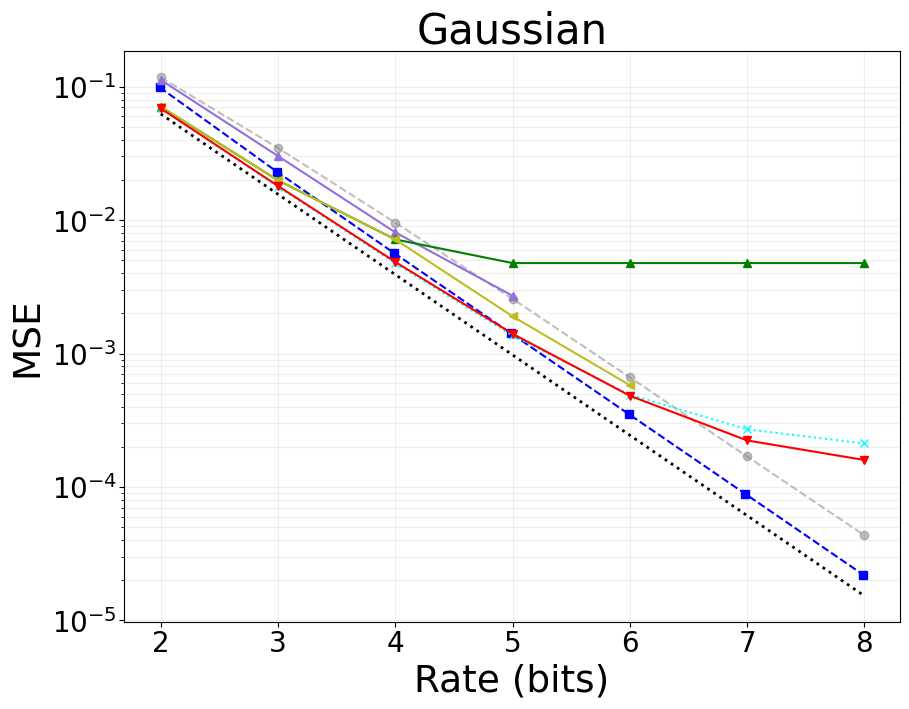


Experiment: Laplace


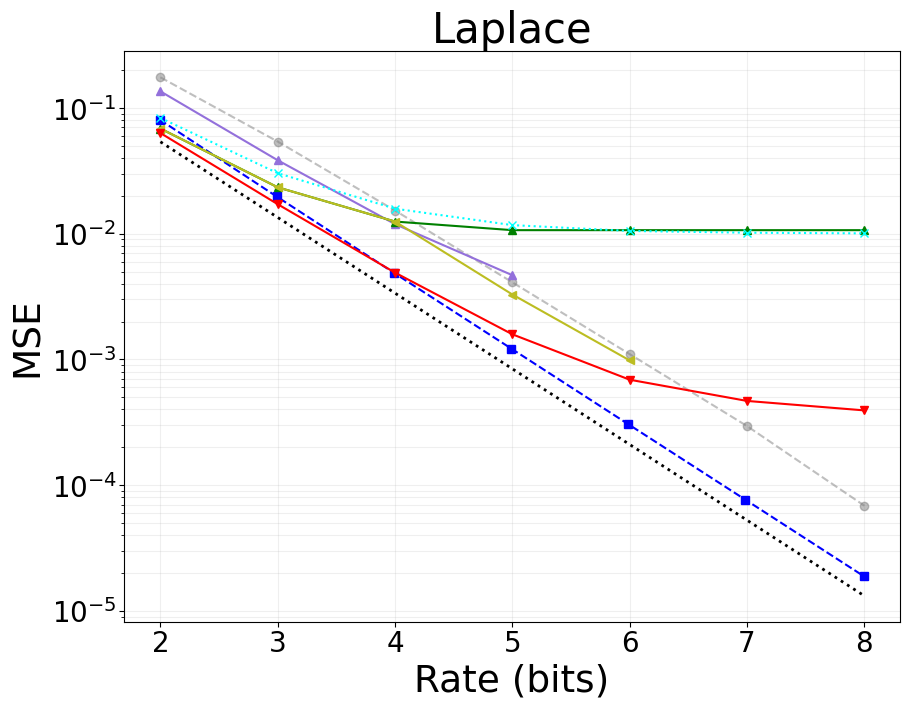


Experiment: Laplace + RHT


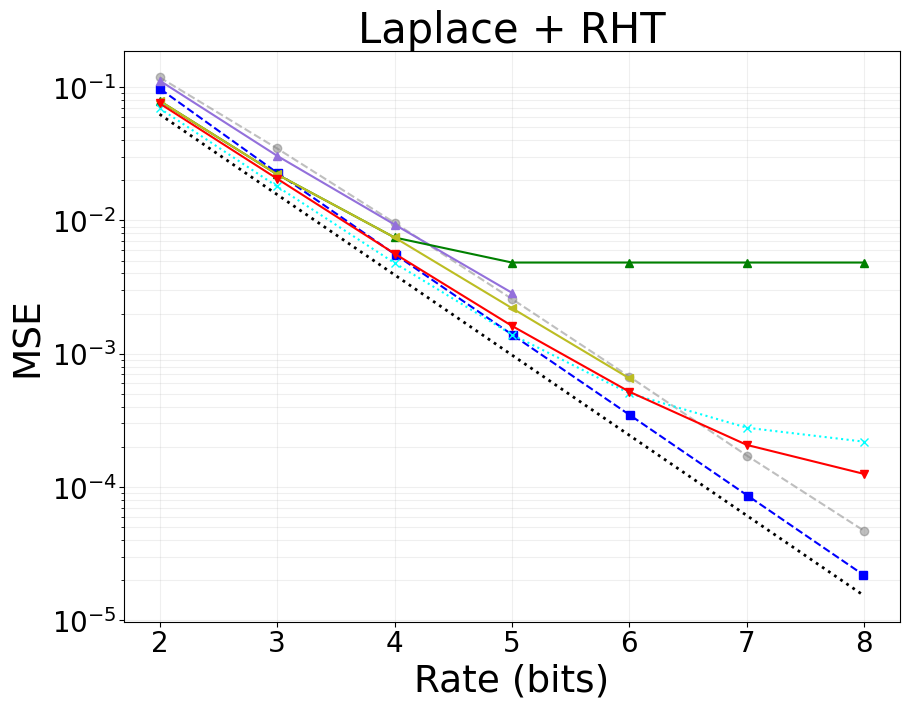


Experiment: Model Weights


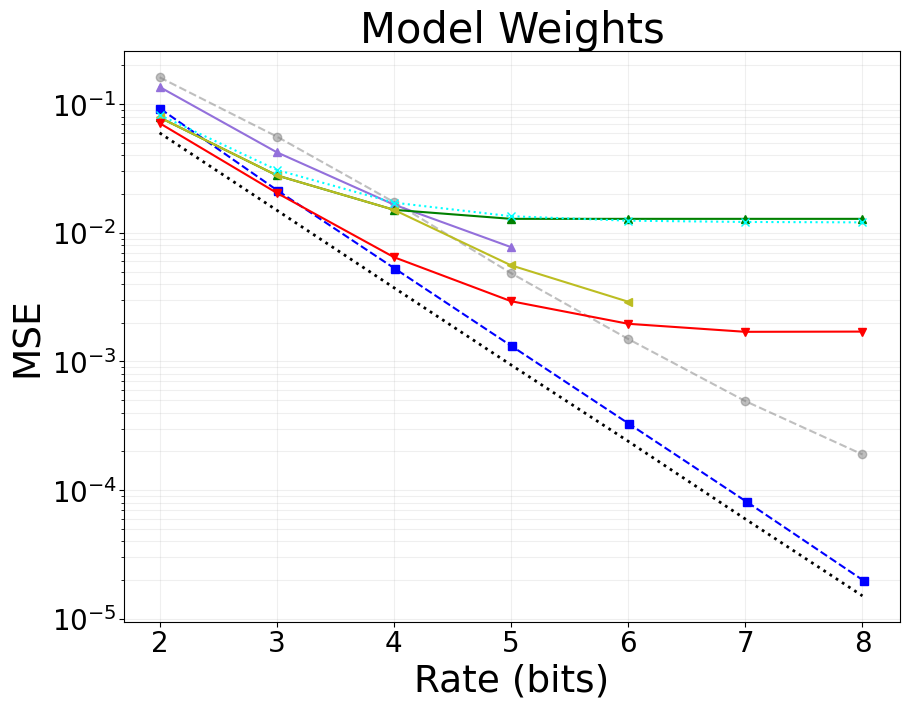


Experiment: Model Weights + RHT


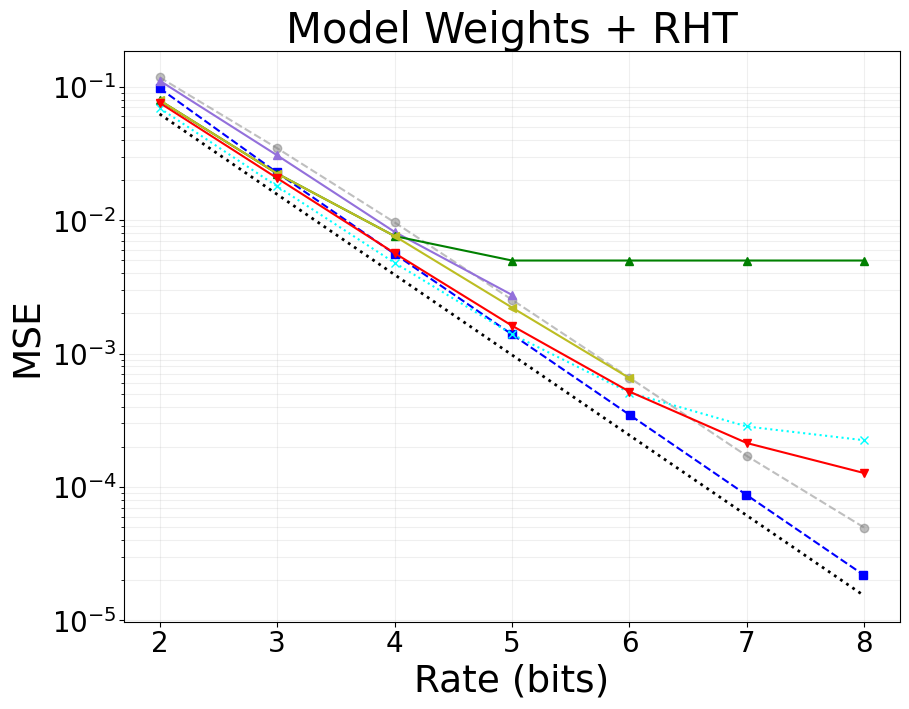

In [20]:
import torch

# Total_results = torch.load('./Total_results2.pkl')
# Total_results = Total_results2
Total_results = torch.load('./toy_codec_comparision/2-9bit_ecsq_tcq.pkl')
Total_results_vq = torch.load('./toy_codec_comparision/2-9bit_vq.pkl')
Total_results_init_laplace = torch.load('./toy_codec_comparision/2-9bit_tcq_init_laplace_1024_256.pkl')
Total_results_init_laplace_hyb2 = torch.load('./toy_codec_comparision/6bit_tcq_init_laplace_1024_256.pkl')
Total_results_init_laplace_ecsq = torch.load('./toy_codec_comparision/ecsq_1024_1.pkl')

for k, v in Total_results.items():
    for kk in ['VQ_d2_Entropy_Rate', 'VQ_d2_Entropy_MSE', 'VQ_d4_Entropy_Rate', 'VQ_d4_Entropy_MSE', 'VQ_d4_MSE', 'VQ_d2_MSE']:
        v[kk] = Total_results_vq[k][kk][:4]
for k, v in Total_results.items():
    for kk in ['2D_TCQ_HYB_laplace', '2D_TCQ_RPTC_laplace', '2D_TCQ_HYB*_laplace']:
        v[kk] = Total_results_init_laplace[k][kk]
for k, v in Total_results.items():
    for kk in ['ECSQ_Rate', 'ECSQ_MSE']:
        v[kk] = Total_results_init_laplace_ecsq[k][kk]


def filter_none(x_list, y_list):
    valid = [(x, y) for x, y in zip(x_list, y_list) if x is not None and y is not None]
    if not valid: return [], []
    return zip(*valid)

params = {
    'font.size': 30,
    'axes.titlesize': 30,
    'axes.labelsize': 27,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    # 'legend.fontsize': 10,
    'figure.titlesize': 32
}
plt.rcParams.update(params)

for source_name, data_gen_func in experiments:
    print(f"\n{'='*40}")
    print(f"Experiment: {source_name}")
    print(f"{'='*40}")
    is_rht = "RHT" in source_name
    
    results = Total_results[source_name]
    # ==========================================
    # Plotting
    # ==========================================
    plt.figure(figsize=(9, 7))
    # vx2, vy2 = filter_none(results["VQ_d2_Entropy_Rate"], results["VQ_d2_Entropy_MSE"])
    # plt.semilogy(vx2, vy2, '^-', label='ECVQ (d=2)', color='mediumpurple')
    # vx4, vy4 = filter_none(results["VQ_d4_Entropy_Rate"], results["VQ_d4_Entropy_MSE"])
    # plt.semilogy(vx4, vy4, 'v-', label='ECVQ (d=4)', color='indigo')
    plt.semilogy(results["R"], results["SQ_Fixed_MSE"], 'o--', label='SQ (Lloyd-Max)', color='gray', alpha=0.5)
    
    plt.semilogy(results["SQ_Ent_Theory_Rate"], results["SQ_Ent_MSE"], 's--', label='ECSQ (d=1)', color='blue')
    # plt.semilogy(results["SQ_rANS_Rate"], results["SQ_Ent_MSE"], '*', label='SQ + Entropy (rANS Actual)', color='orange', zorder=10)
    # plt.semilogy(results["ECSQ_Rate"], results["ECSQ_MSE"], '*--', label='ECSQ (github)')
    
    
    vx2, vy2 = filter_none(results["R"], results["VQ_d2_MSE"])
    plt.semilogy(vx2, vy2, '^-', label='VQ (d=2)', color='mediumpurple')
    # vx4, vy4 = filter_none(results["R"], results["VQ_d4_MSE"])
    # plt.semilogy(vx4, vy4, 'v-', label='VQ (d=4)', color='teal')
    
    if 'model' in source_name.lower() or 'laplace' in source_name.lower():
        x, y = filter_none(results["R"], results["2D_TCQ_HYB_laplace"])
    else:
        x, y = filter_none(results["R"], results["2D_TCQ_HYB"])
    plt.semilogy(x, y, '^-', label='TCQ', color='green')
    # plt.semilogy(x, y, '>-', label='TCQ (HYB, 1D)', color='gold')

    if 'model' in source_name.lower() or 'laplace' in source_name.lower():
        x, y = filter_none(results["R"], results["2D_TCQ_HYB*_laplace"])
    else:
        x, y = filter_none(results["R"], results["2D_TCQ_HYB*"])
    plt.semilogy(x[:5], y[:5], '<-', label='TCQ*', color='tab:olive')

    
    plt.semilogy(results["R"], results["1D_TCQ_1MAD"], 'x:', label='TCQ (1MAD)', color='cyan')
    # plt.semilogy(results["R"], results["1D_TCQ_3INST"], '+:', label='TCQ (3INST)', color='magenta')
    if 'model' in source_name.lower() or 'laplace' in source_name.lower():
        x, y = filter_none(results["R"], results["2D_TCQ_RPTC_laplace"])
    else:
        x, y = filter_none(results["R"], results["2D_TCQ_RPTC"])
    plt.semilogy(x, y, 'v-', label='TCQ (RPTC)', color='red')
    
    # x, y = filter_none(results["R"], results["1D_TCQ_RPTC"])
    # plt.semilogy(x, y, 'P-', label='TCQ (RPTC, 1D)', color='tab:purple')
    
    # Shannon Limit 라벨링 (RHT인 경우 Gaussian Limit임을 명시)
    
    # limit_label = 'Gaussian Limit ($D(R) = \sigma^2 2^{-2R}$)' if is_rht or source_name == 'Gaussian' else 'Shannon Limit (Source)'
    limit_label = 'Gaussian Limit ($D(R) = \sigma^2 2^{-2R}$)' if is_rht or source_name == 'Gaussian' else 'Shannon limit'
    plt.semilogy(results["R"], results["Shannon"], 'k:', label=limit_label, linewidth=2)
    
    
    plt.title(f"{source_name}")
    plt.xlabel("Rate (bits)")
    plt.ylabel("MSE")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    # if source_name.lower() == 'model weights':
        # plt.legend(loc='upper right', ncol=2, frameon=True, edgecolor='black', fancybox=False)
    # plt.legend(ncol=2, frameon=True, fancybox=False)
    # plt.tight_layout()
    # plt.savefig(f'./plot/codec_RD/RD_{source_name}.pdf', dpi=300)
    
        
    # ✅ show 전에 현재 fig/ax에서 handles, labels 추출
    fig = plt.gcf()
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    fig.tight_layout(pad=0.1)  # 0.0~0.3 사이로 조절
    ax.set_title(source_name, pad=4)         # 기본 pad가 커서 위 여백 커짐
    ax.set_xlabel("Rate (bits)", labelpad=4)
    ax.set_ylabel("MSE", labelpad=4)
    ax.tick_params(pad=2)

    # 3) 저장할 때 바깥 여백까지 강제로 크롭
    fig.savefig(f'./plot/codec_RD/RD_{source_name}.pdf',
                dpi=300, bbox_inches='tight', pad_inches=0.02)
            
    # fig.tight_layout()
    # fig.savefig(f'./plot/codec_RD/RD_{source_name}.pdf', dpi=300)

    # ✅ legend만 저장
    fig_leg = plt.figure(figsize=(18, 1.4))
    fig_leg.legend(
        handles, labels,
        loc="center",
        ncol=4,
        frameon=False,
        fancybox=False,
        edgecolor="black",
        fontsize=26,
        columnspacing=1.2,
        handlelength=2.2,
        handletextpad=0.6,
    )
    fig_leg.savefig(f'./plot/codec_RD/legend_{source_name}.pdf',
                    bbox_inches='tight', dpi=300)
    plt.close(fig_leg)
    plt.show()

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# import sys
# import os
# import logging
# import warnings
# from transformers import AutoModelForCausalLM
# import constriction

# plt.rcParams['font.size'] = 16
# plt.rcParams['axes.titlesize'] = 18
# plt.rcParams['axes.labelsize'] = 18
# # plt.rcParams['axes.labelsize'] = 23
# plt.rcParams['xtick.labelsize'] = 16
# plt.rcParams['ytick.labelsize'] = 16
# plt.rcParams['legend.fontsize'] = 16
# # plt.rcParams['legend.fontsize'] = 20
# plt.rcParams['figure.titlesize'] = 20


# # ==========================================
# # 1. 초기 설정 (Imports & Setup)
# # ==========================================
# project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'qtip'))
# if project_root not in sys.path:
#     sys.path.append(project_root)

# from lib.codebook.bitshift import bitshift_codebook
# import torch._dynamo
# import scipy.stats

# # 에러 및 경고 억제
# torch._dynamo.config.suppress_errors = True
# torch._dynamo.reset()
# logging.getLogger('torch._dynamo').setLevel(logging.ERROR)
# logging.getLogger('torch._inductor').setLevel(logging.ERROR)
# warnings.filterwarnings("ignore")

# # 시드 고정
# torch.manual_seed(42)
# np.random.seed(42)

# device = 'cuda:0'
# N_SAMPLES = 4096 * 1  # 유지

# # ==========================================
# # 2. Model Weights 로딩 (User Code Part 1)
# # ==========================================
# print("Loading Model Weights...")

# def get_named_linears(module):
#     return {name: m for name, m in module.named_modules() if isinstance(m, nn.Linear)}

# def get_blocks(model):
#     if model.__class__.__name__ in ("LlamaForCausalLM", "Qwen2ForCausalLM"):
#         layers = model.model.layers
#     else:
#         # 간단한 처리를 위해 Llama 외 모델 생략 (필요 시 기존 코드 참고)
#         raise NotImplementedError(type(model))
#     return layers

# # 모델 경로 설정
# model_list = ['meta-llama/Meta-Llama-3-8B']
# weight_norm = None

# try:
#     for model_name in model_list:
#         model_name_safe = model_name.replace('/', '--')
#         model_path = f"../Wparam_dataset/hf_model/{model_name_safe}"
        
#         if not os.path.exists(model_path):
#             print(f"Warning: Model path {model_path} not found. Skipping Weight experiment.")
#             continue

#         print(f'Loading from: {model_path}')
#         model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True)
#         layers = get_blocks(model)
        
#         weight = []
#         for i in tqdm(range(len(layers)), desc="Extracting Weights"):
#             named_linears = get_named_linears(layers[i])
#             for n, m in named_linears.items():
#                 W = m.weight.data.detach().view(-1)
#                 weight.append(W)
        
#         weight = torch.cat(weight, dim=0)
        
#         # 정규화 (Normalization)
#         mean = weight.mean()
#         std = weight.std()
#         weight_norm = (weight - mean) / std
        
#         print(f"Weights Loaded: Mean={mean.item():.4f}, Std={std.item():.4f}")
#         print(f"Normalized: Mean={weight_norm.mean().item():.4f}, Std={weight_norm.std().item():.4f}")
        
#         # 메모리 정리를 위해 모델 삭제
#         del model
#         torch.cuda.empty_cache()
#         break # 하나만 로드하고 종료

# except Exception as e:
#     print(f"Error loading weights: {e}")
#     weight_norm = None

# # ==========================================
# # 3. Helper Functions & QTIP Runner
# # ==========================================
# def calc_entropy(labels):
#     unique, counts = np.unique(labels, return_counts=True)
#     probs = counts / len(labels)
#     return -np.sum(probs * np.log2(probs + 1e-10))

# def uniform_quantization(x, step_size):
#     if step_size < 1e-6: return x 
#     return np.round(x / step_size) * step_size

# def run_qtip_experiment(data_tensor, decode_mode, K=2, V=2, L=16, tlut_bits=None):
#     if tlut_bits is None:
#         tlut_bits = max(9, 2*K + 2)
        
#     cb = bitshift_codebook(
#         L=L, K=K, V=V, 
#         tlut_bits=tlut_bits, 
#         decode_mode=decode_mode
#     ).to(device)
    
#     # 입력 처리: (Batch, BlockSize=256)
#     data_in = data_tensor.view(-1, 256).to(device)
    
#     with torch.no_grad():
#         q_out = cb.quantize(data_in)
#         recon = q_out[0]
#         mse = torch.mean((data_in - recon) ** 2).item()
        
#     return mse


# def get_shannon_limit(data_np, R, source_name):
#     """
#     데이터 분포에 따른 정확한 Shannon Lower Bound (SLB) 계산
#     D(R) = (1 / 2*pi*e) * 2^(2*h(X)) * 2^(-2R)
#     """
#     sigma_sq = np.var(data_np)
    
#     if "Gaussian" in source_name:
#         # Gaussian SLB: sigma^2 * 2^(-2R)
#         return sigma_sq * (2 ** (-2 * R))
        
#     elif "Laplace" in source_name:
#         # Laplace SLB: (e/pi) * sigma^2 * 2^(-2R)
#         return (np.e / np.pi) * sigma_sq * (2 ** (-2 * R))
        
#     else:
#         # Model Weights 등 일반적인 분포: 미분 엔트로피(h)를 직접 추정하여 계산
#         # scipy를 이용해 미분 엔트로피 추정 (Vasicek's estimator)
#         # 데이터가 너무 많으면 느리므로 샘플링해서 계산
#         sample_for_ent = data_np if len(data_np) < 20000 else np.random.choice(data_np, 20000)
#         h_X = scipy.stats.differential_entropy(sample_for_ent, method='vasicek')
        
#         # 일반 SLB 공식: (1 / 2*pi*e) * e^(2*h) * 2^(-2R)  <-- h가 natural log 기반일 때
#         # 위 수식의 2^(2h(X)) 부분은 h의 밑이 2일 때이고, scipy는 밑이 e이므로 e^(2h)를 씀
#         coeff = (1.0 / (2 * np.pi * np.e)) * np.exp(2 * h_X)
#         return coeff * (2 ** (-2 * R))
# # ==========================================
# # 4. Data Generators
# # ==========================================
# def get_gaussian_data():
#     return torch.randn(N_SAMPLES)

# def get_laplace_data():
#     m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0 / np.sqrt(2)]))
#     return m.sample((N_SAMPLES,)).squeeze()

# def get_weight_data():
#     if weight_norm is None:
#         raise ValueError("Weights not loaded properly.")
#     # 전체 웨이트에서 랜덤 샘플링
#     indices = torch.randint(0, len(weight_norm), (N_SAMPLES,))
#     return weight_norm[indices]


# def run_actual_rans(data_np, step_size):
#     """
#     실제 rANS 인코더를 사용하여 압축 비트레이트를 측정합니다.
#     """
#     # 1. 양자화 (Quantization)
#     # 데이터를 정수로 변환 (인덱스)
#     q_indices = np.round(data_np / step_size).astype(np.int32)
    
#     # 2. 심볼 오프셋 조정 (constriction은 0부터 시작하는 양의 정수 필요)
#     min_val = q_indices.min()
#     symbols = q_indices - min_val # 0, 1, 2, ... 로 변환
#     symbols = symbols.astype(np.int32) # constriction은 int32 요구
    
#     # 3. 확률 모델 생성 (Frequency Table)
#     # 실제 압축에선 이 'probs' 정보도 헤더에 저장해야 하지만, 
#     # 여기선 Raw Data Stream의 압축 효율만 비교합니다.
#     unique, counts = np.unique(symbols, return_counts=True)
    
#     # 빈 심볼도 포함하여 확률 테이블 생성 (max_val 까지)
#     max_sym = symbols.max()
#     freqs = np.zeros(max_sym + 1, dtype=np.float64)
#     freqs[unique] = counts
    
#     # 확률 정규화 (총합 1)
#     probs = freqs / freqs.sum()
    
#     # rANS용 엔트로피 모델 정의
#     # (Perfect quantization assumption: Categorical distribution)
#     model = constriction.stream.model.Categorical(probs)
    
#     # 4. 인코딩 (Encoding)
#     coder = constriction.stream.stack.AnsCoder()
#     # 인코더에 데이터 주입 (Stack 방식이라 reverse로 넣는 것이 일반적이나, 순서는 bpp에 영향 없음)
#     coder.encode_reverse(symbols, model)
    
#     # 5. 비트레이트 계산 (Measurement)
#     # get_compressed()는 32-bit words(4 bytes) 배열을 반환합니다.
#     compressed_data = coder.get_compressed() 
#     total_bits = len(compressed_data) * 32 
    
#     actual_bpp = total_bits / len(data_np)
    
#     return actual_bpp

# # 실험 대상 목록 정의
# experiments = [
#     ("Gaussian", get_gaussian_data),
#     ("Laplace", get_laplace_data),
# ]

# if weight_norm is not None:
#     experiments.append(("Model Weights", get_weight_data))

# # ==========================================
# # 5. Main Experiment Loop (Iterate Sources)
# # ==========================================
# R_targets = [2, 3, 4, 5, 6] 

# for source_name, data_gen_func in experiments:
#     print(f"\n{'='*40}")
#     print(f"Running Experiment: {source_name}")
#     print(f"{'='*40}")
    
#     # 데이터 생성
#     data = data_gen_func()
#     data_np = data.numpy()
    
#     print(f"[{source_name}] Stats: Mean={data.mean():.4f}, Std={data.std():.4f} (Target Std=1.0)")

#     # results = {
#     #     "R": [], "Shannon": [], "SQ_Fixed": [], "SQ_Entropy": [],
#     #     "1D_TCQ_1MAD": [], "1D_TCQ_3INST": [], "2D_TCQ_HYB": [], "2D_TCQ_RPTC": []
#     # }
#     results = {
#         "R_Target": [],       # 목표 Rate (Loop 기준)
#         "Shannon": [],        # Shannon Limit
#         "SQ_Fixed_MSE": [],   # SQ (Lloyd-Max) MSE
#         "SQ_Ent_Theory_Rate": [], # 이론적 엔트로피 (X축)
#         "SQ_Ent_MSE": [],         # SQ + Entropy MSE (Y축)
#         "SQ_rANS_Rate": [],       # [NEW] 실제 rANS BPP (X축)
#         "1D_TCQ_1MAD": [], "1D_TCQ_3INST": [], "2D_TCQ_HYB": [], "2D_TCQ_RPTC": []
#     }

#     print("-" * 105)
#     print(f"{'Rate':<5} | {'Shannon':<10} | {'SQ(Fix)':<10} | {'SQ(Ent)':<10} | {'1MAD':<10} | {'3INST':<10} | {'HYB':<10} | {'RPTC':<10}")
#     print("-" * 105)

#     for R_target in tqdm(R_targets, desc=f"Simulating ({source_name})"):
#         # results["R"].append(R_target)
#         results["R_Target"].append(R_target)
        
#         D_shannon = get_shannon_limit(data_np, R_target, source_name)
#         results["Shannon"].append(D_shannon)

#         # 2. SQ (Lloyd-Max)
#         n_clusters = 2 ** R_target
#         kmeans = KMeans(n_clusters=n_clusters, n_init=3, max_iter=50, random_state=42)
#         kmeans.fit(data_np.reshape(-1, 1))
#         sq_mse = kmeans.inertia_ / N_SAMPLES
#         results["SQ_Fixed_MSE"].append(sq_mse)

#         # 3. SQ + Entropy
#         low, high = 0.001, 10.0
#         best_step = 1.0
#         for _ in range(20): 
#             mid = (low + high) / 2
#             q_vals = np.round(data_np / mid)
#             h = calc_entropy(q_vals)
#             if h > R_target: low = mid
#             else: high = mid; best_step = mid
        
#         ecsq_recon = uniform_quantization(data_np, best_step)
#         ecsq_mse = np.mean((data_np - ecsq_recon)**2)
        
#         # [A] Theoretical Rate (Entropy)
#         q_vals_full = np.round(data_np / best_step)
#         theory_rate = calc_entropy(q_vals_full)
        
#         # [B] Actual Rate (rANS)
#         rans_rate = run_actual_rans(data_np, best_step)
        
#         # 결과 저장
#         results["SQ_Ent_Theory_Rate"].append(theory_rate) # X1
#         results["SQ_rANS_Rate"].append(rans_rate)         # X2 (New)
#         results["SQ_Ent_MSE"].append(ecsq_mse)            # Y (Common)
#         # results["SQ_Entropy"].append(ecsq_mse)

#         # 4. TCQ Experiments
#         # 1MAD
#         tcq_1mad = run_qtip_experiment(data, decode_mode='1mad', K=R_target, V=1, tlut_bits=0)
#         results["1D_TCQ_1MAD"].append(tcq_1mad)
        
#         # 3INST
#         tcq_3inst = run_qtip_experiment(data, decode_mode='3inst', K=R_target, V=1, tlut_bits=0)
#         results["1D_TCQ_3INST"].append(tcq_3inst)

#         # HYB (2D, Quantized LUT)
#         tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None)
#         results["2D_TCQ_HYB"].append(tcq_hyb)
        
#         # RPTC (2D, Full LUT)
#         tcq_rptc = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=2, tlut_bits=16)
#         results["2D_TCQ_RPTC"].append(tcq_rptc)

#         print(f"{R_target:<5} | {D_shannon:<10.5f} | {sq_mse:<10.5f} | {ecsq_mse:<10.5f} | {tcq_1mad:<10.5f} | {tcq_3inst:<10.5f} | {tcq_hyb:<10.5f} | {tcq_rptc:<10.5f}")

#     # ==========================================
#     # Plotting (Per Source)
#     # ==========================================
#     plt.figure(figsize=(9, 7))
#     plt.semilogy(results["R"], results["SQ_Fixed"], 'o--', label='SQ (Lloyd-Max)', color='gray', alpha=0.5)
#     plt.semilogy(results["R"], results["SQ_Entropy"], 's--', label='SQ + Entropy', color='blue')
#     plt.semilogy(results["R"], results["1D_TCQ_1MAD"], 'x:', label='1D TCQ (1MAD)', color='cyan')
#     plt.semilogy(results["R"], results["1D_TCQ_3INST"], '+:', label='1D TCQ (3INST)', color='magenta')
#     plt.semilogy(results["R"], results["2D_TCQ_HYB"], '^-', label='2D TCQ (HYB)', color='green')
#     plt.semilogy(results["R"], results["2D_TCQ_RPTC"], 'v-', label='2D TCQ (RPTC)', color='red')
#     plt.semilogy(results["R"], results["Shannon"], 'k:', label='Shannon Limit ($D_\infty$)', linewidth=2)

#     plt.title(f"Rate-Distortion Curve: {source_name}")
#     plt.xlabel("Rate (bits per sample)")
#     plt.ylabel("MSE (Distortion) - Log Scale")
#     plt.grid(True, which="both", ls="-", alpha=0.2)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()